In [ ]:
from google.colab import drive
drive.mount('/content/drive')


# Extracting the Data


In [4]:
import os
import pandas as pd

data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/forecasting"
energy_data = os.path.join(data_path, "energy_dataset.csv")
energy_data = pd.read_csv(energy_data)
energy_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [7]:
energy_data.shape

(35064, 29)

In [8]:
energy_data.columns

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')

# Data Visualization

## Monthly

In [12]:
vis_df = energy_data.copy()
vis_df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [15]:
vis_df['time'] = pd.to_datetime(vis_df['time'], utc=True)
vis_df_monthly = vis_df.set_index('time').resample('ME').mean().reset_index()

vis_df_monthly.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,196.000000,0.0,6378.000000,17.000000,NaN,6436.000000,26118.000000,25385.000000,50.100000,65.410000
1,2015-01-31 00:00:00+00:00,483.716235,572.843111,0.0,4849.984993,5411.347885,306.030014,0.0,0.0,0.0,...,228.884038,0.0,7583.579809,1122.850806,NaN,7589.591398,30117.932796,29997.428765,47.419395,64.898763
2,2015-02-28 00:00:00+00:00,470.226190,313.416667,0.0,4675.349702,4047.590774,319.404762,0.0,0.0,0.0,...,213.821429,0.0,7729.565476,1207.175595,NaN,7721.244048,29618.687500,29478.727685,44.206295,56.412991
3,2015-03-31 00:00:00+00:00,468.071237,244.405914,0.0,4615.216398,4236.115591,319.208333,0.0,0.0,0.0,...,177.245968,0.0,6750.033602,1321.659946,NaN,6716.736559,28385.888441,28431.045699,46.556801,55.478562
4,2015-04-30 00:00:00+00:00,426.409471,463.247911,0.0,4952.200557,4819.632312,338.793872,0.0,0.0,0.0,...,192.327298,0.0,5496.034819,1449.394444,NaN,5482.701389,27453.072222,27438.268156,48.900778,58.402806


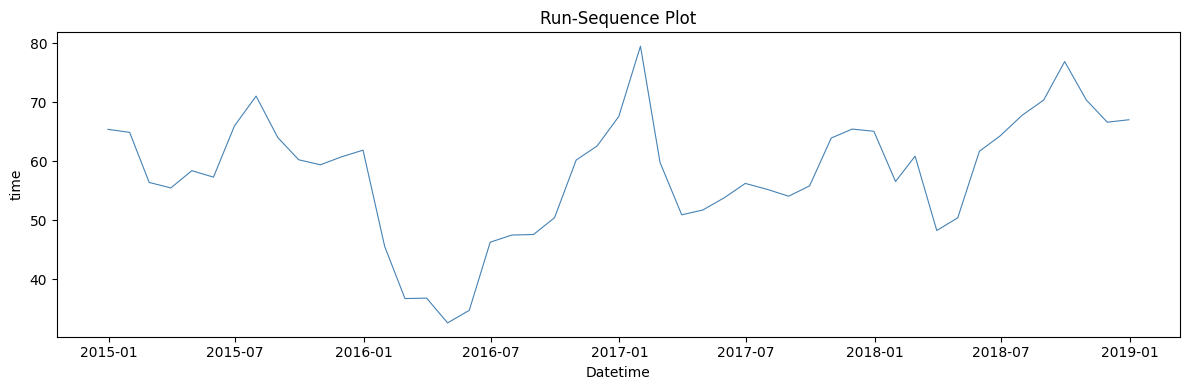

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(vis_df_monthly.time, vis_df_monthly['price actual'],
         linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel(vis_df_monthly.columns[0])
plt.tight_layout()
plt.show()

## Daily

In [17]:
vis_df = energy_data.copy()
vis_df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [18]:
vis_df['time'] = pd.to_datetime(vis_df['time'], utc=True)
vis_df_daily = vis_df.set_index('time').resample('D').mean().reset_index()

vis_df_daily.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,196.000000,0.0,6378.000000,17.000000,NaN,6436.000000,26118.000000,25385.000000,50.100000,65.410000
1,2015-01-01 00:00:00+00:00,425.208333,243.708333,0.0,4187.791667,4099.458333,161.500000,0.0,0.0,0.0,...,201.041667,0.0,3994.000000,1049.500000,NaN,3942.416667,24753.250000,23966.958333,45.031667,62.090833
2,2015-01-02 00:00:00+00:00,389.875000,0.000000,0.0,3566.166667,1258.125000,200.833333,0.0,0.0,0.0,...,186.583333,0.0,11060.041667,1187.208333,NaN,11117.041667,27519.416667,27188.541667,17.598333,69.443750
3,2015-01-03 00:00:00+00:00,436.875000,0.000000,0.0,3451.791667,1375.958333,229.791667,0.0,0.0,0.0,...,202.333333,0.0,9137.250000,1133.375000,NaN,9113.416667,25500.833333,25097.750000,25.342083,65.223333
4,2015-01-04 00:00:00+00:00,396.375000,13.583333,0.0,3526.125000,2315.291667,356.625000,0.0,0.0,0.0,...,159.125000,0.0,8016.125000,2292.041667,NaN,8022.833333,27167.875000,27104.916667,30.658333,58.912083


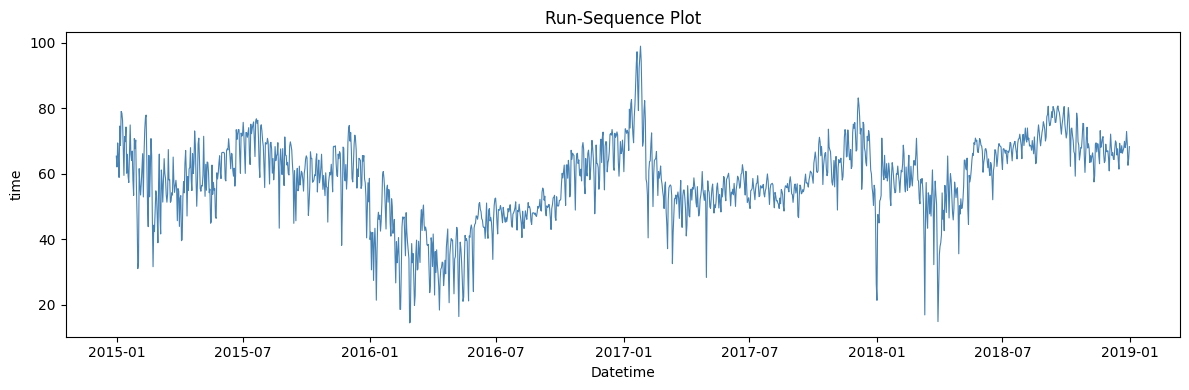

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(vis_df_daily.time, vis_df_daily['price actual'],
         linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel(vis_df_daily.columns[0])
plt.tight_layout()
plt.show()

## PACF and ACF

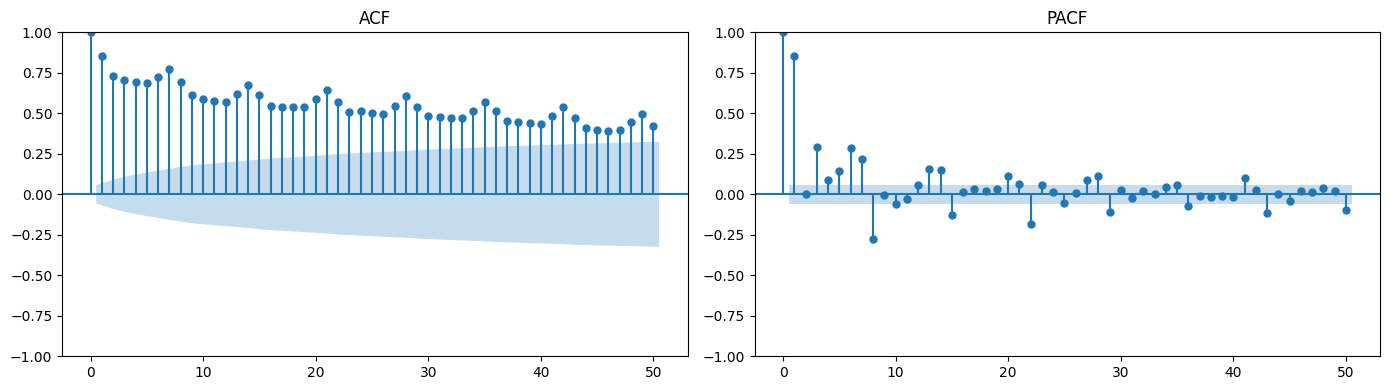

In [37]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train['price actual'].dropna(),  lags=50, ax=axes[0])
plot_pacf(train['price actual'].dropna(), lags=50, method='ywm', ax=axes[1])

axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

# Transforming the data

In [23]:
# From hourly to daily

energy_data['time'] = pd.to_datetime(energy_data['time'], utc=True)
energy_data = vis_df.set_index('time').resample('D').mean().reset_index()

energy_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,196.000000,0.0,6378.000000,17.000000,NaN,6436.000000,26118.000000,25385.000000,50.100000,65.410000
1,2015-01-01 00:00:00+00:00,425.208333,243.708333,0.0,4187.791667,4099.458333,161.500000,0.0,0.0,0.0,...,201.041667,0.0,3994.000000,1049.500000,NaN,3942.416667,24753.250000,23966.958333,45.031667,62.090833
2,2015-01-02 00:00:00+00:00,389.875000,0.000000,0.0,3566.166667,1258.125000,200.833333,0.0,0.0,0.0,...,186.583333,0.0,11060.041667,1187.208333,NaN,11117.041667,27519.416667,27188.541667,17.598333,69.443750
3,2015-01-03 00:00:00+00:00,436.875000,0.000000,0.0,3451.791667,1375.958333,229.791667,0.0,0.0,0.0,...,202.333333,0.0,9137.250000,1133.375000,NaN,9113.416667,25500.833333,25097.750000,25.342083,65.223333
4,2015-01-04 00:00:00+00:00,396.375000,13.583333,0.0,3526.125000,2315.291667,356.625000,0.0,0.0,0.0,...,159.125000,0.0,8016.125000,2292.041667,NaN,8022.833333,27167.875000,27104.916667,30.658333,58.912083


# ARIMA

## Train - Test Split

In [24]:

# 80% train 20% validation
split_index = int(len(energy_data) * 0.80)

train = energy_data.iloc[:split_index]
test  = energy_data.iloc[split_index:]

print(f"Total observations : {len(energy_data)}")
print(f"Train size: {len(train)} ({len(train)/len(energy_data)*100:.2f}%)")
print(f"Test size: {len(test)}  ({len(test)/len(energy_data)*100:.2f}%)")
print(f"\nTrain period: {train.index[0]} → {train.index[-1]}")
print(f"Test period : {test.index[0]} → {test.index[-1]}")

Total observations : 1462
Train size: 1169 (79.96%)
Test size: 293  (20.04%)

Train period: 0 → 1168
Test period : 1169 → 1461


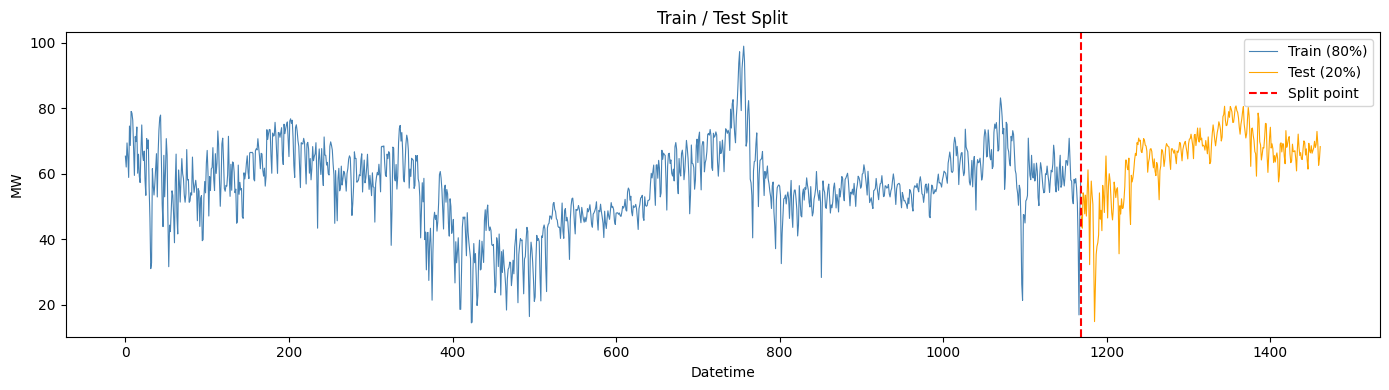

In [36]:

plt.figure(figsize=(14, 4))
plt.plot(train.index, train['price actual'], label="Train (80%)", color="steelblue", linewidth=0.8)
plt.plot(test.index,  test['price actual'],  label="Test (20%)",  color="orange",    linewidth=0.8)
plt.axvline(x=test.index[0], color="red", linestyle="--", label="Split point")
plt.title("Train / Test Split")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

## Model Training

In [38]:
import itertools
import warnings
import statsmodels.api as sm
warnings.filterwarnings("ignore")

p_range = range(0, 4)
d_range = [0]
q_range = range(0, 4)

aic_results = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = sm.tsa.ARIMA(train['price actual'], order=(p, d, q)).fit()
        aic_results.append({"p": p, "d": d, "q": q, "AIC": round(model.aic, 2)})
    except:
        continue

aic_df = pd.DataFrame(aic_results).sort_values("AIC")
print(aic_df.head(10))

best = aic_df.iloc[0]
optimal_p, optimal_d, optimal_q = int(best.p), int(best.d), int(best.q)
print(f"\nOptimal Order: ARIMA({optimal_p}, {optimal_d}, {optimal_q})")

    p  d  q      AIC
15  3  0  3  7385.19
6   1  0  2  7401.65
7   1  0  3  7401.95
10  2  0  2  7402.15
14  3  0  2  7402.25
11  2  0  3  7403.84
13  3  0  1  7405.03
12  3  0  0  7473.77
9   2  0  1  7551.17
4   1  0  0  7579.89

Optimal Order: ARIMA(3, 0, 3)


In [59]:
arima_model = sm.tsa.ARIMA(
    train['price actual'],
    order=(optimal_p, optimal_d, optimal_q)
).fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:           price actual   No. Observations:                 1169
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -3786.914
Date:                Wed, 01 Apr 2026   AIC                           7581.828
Time:                        13:19:07   BIC                           7602.084
Sample:                             0   HQIC                          7589.468
                               - 1169                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.1147      1.360     41.275      0.000      53.450      58.779
ar.L1          0.8593      0.016     54.741      0.000       0.829       0.890
ma.L1         -0.0154      0.031     -0.499      0.6

In [60]:
arima_pred_obj = arima_model.apply(test['price actual']).get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)
arima_preds = arima_pred_obj.predicted_mean

arima_preds.index = test.index


## Metrics and Visualization

In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Grid search over window sizes
windows = range(2, 49)  # test windows 2–48
results = []

for w in windows:
    # Rolling mean on train, predict on test
    preds = energy_data['price actual'].shift(1).rolling(w).mean().iloc[split_index:]
    actuals = test['price actual']

    # Align (drop NaNs)
    mask = preds.notna()
    rmse = np.sqrt(mean_squared_error(actuals[mask], preds[mask]))
    results.append({"window": w, "rmse": rmse})

results_df = pd.DataFrame(results)
optimal_window = results_df.loc[results_df.rmse.idxmin(), "window"]
print(results_df.sort_values("rmse").head(10))
print(f"\nOptimal Window: {optimal_window}")

   window      rmse
5       7  5.289253
4       6  5.335230
0       2  5.351039
6       8  5.351173
2       4  5.354944
3       5  5.373912
1       3  5.402442
7       9  5.418604
8      10  5.513486
9      11  5.630576

Optimal Window: 7


In [62]:
sma_preds = energy_data['price actual'].shift(1).rolling(optimal_window).mean()\
            .iloc[split_index:]

mask = sma_preds.notna()
sma_preds = sma_preds[mask]
test_aligned = test['price actual'][mask]

In [63]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train['price actual']).fit(optimized=True)
ses_preds = ses_model.forecast(len(test))
ses_preds.index = test.index

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def get_metrics(actuals, preds, model_name):
    mae  = mean_absolute_error(actuals, preds)
    rmse = mean_squared_error(actuals, preds)
    mask = actuals.values != 0
    mape = np.mean(np.abs((actuals.values[mask] - preds.values[mask]) /
                           actuals.values[mask])) * 100
    return {"Model": model_name, "MAE": round(mae,2), "MSE": round(rmse,2),
            "MAPE(%)": round(mape,2)}

metrics = pd.DataFrame([
    get_metrics(test_aligned, sma_preds, f"SMA (window={optimal_window})"),
    get_metrics(test['price actual'], ses_preds, "SES"),
])
print(metrics.to_string(index=False))

         Model   MAE    MSE  MAPE(%)
SMA (window=7)  3.58  27.98     6.72
           SES 15.00 272.38    23.15


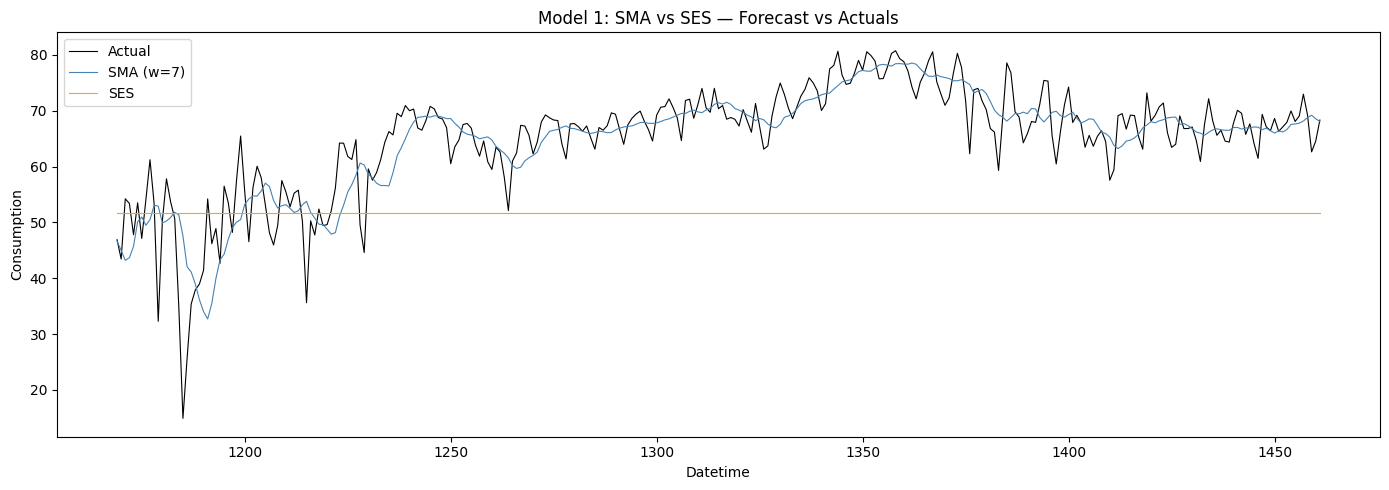

In [65]:

plt.figure(figsize=(14, 5))
plt.plot(test.index, test['price actual'], label="Actual", color="black",
         linewidth=0.8)
plt.plot(sma_preds.index, sma_preds, label=f"SMA (w={optimal_window})",
         color="steelblue", linewidth=0.8)
plt.plot(test.index, ses_preds, label="SES",
         color="orange", linewidth=0.8)
plt.title("Model 1: SMA vs SES — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("Consumption")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:

arima_metrics = get_metrics(
    test['price actual'], arima_preds,
    f"ARIMA({optimal_p},{optimal_d},{optimal_q})"
)
print(pd.DataFrame([arima_metrics]))

          Model    MAE     MSE  MAPE(%)
0  ARIMA(3,0,3)  11.75  174.14    18.82


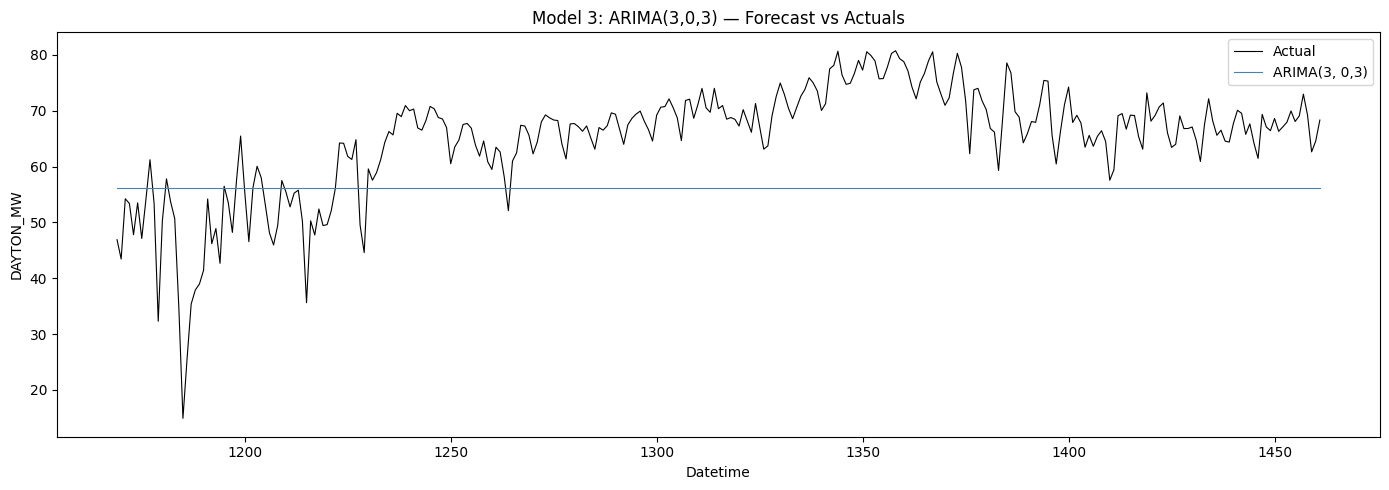

In [67]:

plt.figure(figsize=(14, 5))
plt.plot(test.index, test['price actual'], label="Actual", color="black",
         linewidth=0.8)
plt.plot(arima_preds.index, arima_preds,
         label=f"ARIMA({optimal_p}, {optimal_d},{optimal_q})",
         color="steelblue", linewidth=0.8)
plt.title(f"Model 3: ARIMA({optimal_p},{optimal_d},{optimal_q}) — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("DAYTON_MW")
plt.legend()
plt.tight_layout()
plt.show()